In [1]:
# # required installs
!pip install geopandas shapely
!pip install --upgrade pandas numpy

  Using cached geopandas-1.1.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached shapely-2.1.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
  Using cached pyogrio-0.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.3 kB)
  Using cached pyproj-3.7.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (31 kB)
Using cached geopandas-1.1.1-py3-none-any.whl (338 kB)
Using cached shapely-2.1.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.1 MB)
Using cached pyogrio-0.11.0-cp312-cp312-manylinux_2_28_x86_64.whl (27.7 MB)
Using cached pyproj-3.7.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]
  Using cached pandas-2.3.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (91 kB)
  Using cached numpy-2.3.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached pandas-2.3.1-cp312-cp312-manylinux_2_17_x86_6

In [2]:
!pip install geopy

  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geographiclib-2.0-py3-none-any.whl.metadata (1.4 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.0-py3-none-any.whl (40 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geopy]


In [1]:
# required imports
import pandas as pd
import numpy as np
import geopandas as gpd
import zipfile
import os
import logging
import time
import gc
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
from datetime import datetime
from shapely.geometry import Point, LineString
from shapely.ops import nearest_points
from typing import Optional
from geopy.distance import geodesic
from typing import Optional, List, Dict, Any

import warnings
warnings.filterwarnings('ignore')

In [2]:
import boto3
import pandas as pd
import io
from botocore.exceptions import ClientError
from shapely.geometry import Point, Polygon
import math
import numpy as np
import pandas as pd
from typing import Optional, Union, Tuple
import json
from ipywidgets import interact, FloatSlider, Layout
import ipywidgets as widgets
from shapely.vectorized import contains
import s3fs

In [3]:
# Initialize boto3 session and get credentials
session = boto3.Session()
credentials = session.get_credentials()

# Initialize S3 filesystem with boto3 credentials
s3 = s3fs.S3FileSystem(
    key=credentials.access_key,
    secret=credentials.secret_key,
    token=credentials.token,  # This will be included if using temporary credentials
    anon=False
)
# Read the parquet file
birds = pd.read_parquet('s3://birdsbucker/sk_generated/ebirds_combined.parquet', filesystem=s3)



In [4]:
print( "birds", len(birds))

birds 21572821


In [5]:
birds.columns

Index(['TAXONOMIC ORDER', 'CATEGORY', 'TAXON CONCEPT ID', 'COMMON NAME',
       'SCIENTIFIC NAME', 'EXOTIC CODE', 'OBSERVATION COUNT', 'BREEDING CODE',
       'BREEDING CATEGORY', 'BEHAVIOR CODE', 'AGE/SEX', 'STATE', 'COUNTY',
       'ATLAS BLOCK', 'LOCALITY', 'LOCALITY ID', 'LOCALITY TYPE', 'LATITUDE',
       'LONGITUDE', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED',
       'OBSERVER ID', 'OBSERVER ORCID ID', 'OBSERVATION TYPE',
       'DURATION MINUTES', 'EFFORT DISTANCE KM', 'EFFORT AREA HA',
       'NUMBER OBSERVERS', 'ALL SPECIES REPORTED', 'GROUP IDENTIFIER',
       'hour_started', 'year_record', 'month_record', 'season'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71870 entries, 0 to 71869
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   GLOBAL UNIQUE IDENTIFIER    71870 non-null  object
 1   LAST EDITED DATE            71870 non-null  object
 2   TAXONOMIC ORDER             71870 non-null  object
 3   CATEGORY                    71870 non-null  object
 4   TAXON CONCEPT ID            71870 non-null  object
 5   COMMON NAME                 71870 non-null  object
 6   SCIENTIFIC NAME             71870 non-null  object
 7   SUBSPECIES COMMON NAME      71870 non-null  object
 8   SUBSPECIES SCIENTIFIC NAME  71870 non-null  object
 9   EXOTIC CODE                 71870 non-null  object
 10  OBSERVATION COUNT           71870 non-null  object
 11  BREEDING CODE               71870 non-null  object
 12  BREEDING CATEGORY           71870 non-null  object
 13  BEHAVIOR CODE               7187

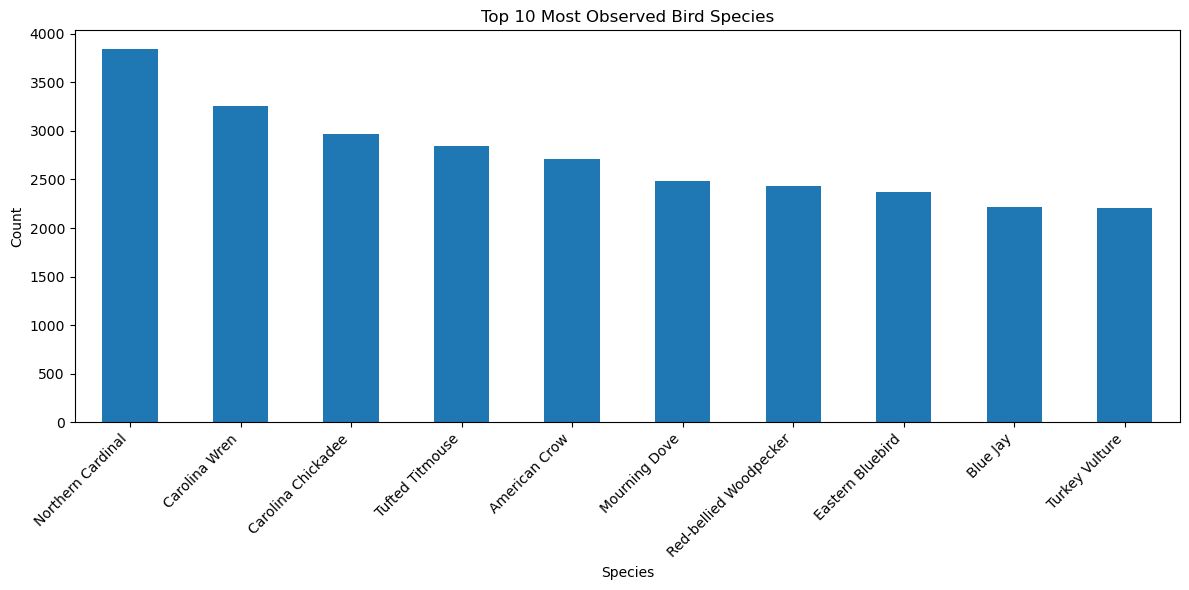

In [7]:
# 1. Basic Information About the Dataset
print("Dataset Info:")
print(birds.info())

print("\nFirst few rows of the dataset:")
print(birds.head())

# 2. Basic Statistics
print("\nBasic Statistics:")
print(birds.describe())

# 3. Check for Missing Values
print("\nMissing Values:")
print(birds.isnull().sum())

# 4. Unique Values in Categorical Columns
print("\nUnique Values in Each Column:")
for column in birds.select_dtypes(include=['object']).columns:
    print(f"\n{column}:")
    print(birds[column].value_counts().head())

# 5. Visualizations
import matplotlib.pyplot as plt
import seaborn as sns



# 5.1 Top 10 Most Common Bird Species
plt.figure(figsize=(12, 6))
birds['COMMON NAME'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Observed Bird Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5.2 Observations Over Time (if date column exists)
if 'OBSERVATION DATE' in birds.columns:
    plt.figure(figsize=(12, 6))
    birds['OBSERVATION DATE'].value_counts().sort_index().plot(kind='line')
    plt.title('Observations Over Time')
    plt.xlabel('Date')
    plt.ylabel('Number of Observations')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5.3 Distribution of Observations by Location (if location columns exist)
if 'locality' in birds.columns:
    plt.figure(figsize=(12, 6))
    birds['locality'].value_counts().head(10).plot(kind='bar')
    plt.title('Top 10 Observation Locations')
    plt.xlabel('Location')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 5.4 Count Distribution (if count column exists)
if 'observation_count' in birds.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(birds['observation_count'], bins=30)
    plt.title('Distribution of Bird Count per Observation')
    plt.xlabel('Count')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# 6. Summary Statistics by Species (if relevant columns exist)
if 'observation_count' in birds.columns and 'common_name' in birds.columns:
    print("\nSummary Statistics by Species (Top 5):")
    species_stats = birds.groupby('common_name')['observation_count'].agg(['count', 'mean', 'std', 'min', 'max']).sort_values('count', ascending=False).head()
    print(species_stats)

In [13]:
import pandas as pd

# Convert OBSERVATION DATE to datetime format
birds['OBSERVATION DATE'] = pd.to_datetime(birds['OBSERVATION DATE'])

# Create new columns for year, month, day, and hour
birds['Year'] = birds['OBSERVATION DATE'].dt.year
birds['Month'] = birds['OBSERVATION DATE'].dt.month
birds['Day'] = birds['OBSERVATION DATE'].dt.day
birds['Hour'] = birds['OBSERVATION DATE'].dt.hour

# Add month names and abbreviated month names
birds['Month_Name'] = birds['OBSERVATION DATE'].dt.strftime('%B')
birds['Month_Abbrev'] = birds['OBSERVATION DATE'].dt.strftime('%b')

# Convert temporal columns to integer type
birds['Year'] = birds['Year'].astype(int)
birds['Month'] = birds['Month'].astype(int)
birds['Day'] = birds['Day'].astype(int)
birds['Hour'] = birds['Hour'].astype(int)

# Add additional time-based columns
birds['Weekday'] = birds['OBSERVATION DATE'].dt.day_name()
birds['Quarter'] = birds['OBSERVATION DATE'].dt.quarter
birds['Week_of_Year'] = birds['OBSERVATION DATE'].dt.isocalendar().week

# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

birds['Season'] = birds['Month'].apply(get_season)

# Validate the new columns
def validate_temporal_columns(df):
    print("Validation Results:")
    print(f"Year range: {df['Year'].min()} to {df['Year'].max()}")
    print(f"Month range: {df['Month'].min()} to {df['Month'].max()}")
    print(f"Day range: {df['Day'].min()} to {df['Day'].max()}")
    print(f"Hour range: {df['Hour'].min()} to {df['Hour'].max()}")
    
    # Check for any null values
    nulls = df[['Year', 'Month', 'Day', 'Hour']].isnull().sum()
    print("\nNull values in temporal columns:")
    print(nulls)

# Display results
print("Sample of new temporal columns:")
print(birds[['OBSERVATION DATE', 'Year', 'Month', 'Day', 'Hour', 'Month_Name', 'Season', 'Weekday']].head())

print("\nShape of DataFrame:", birds.shape)

# Run validation
validate_temporal_columns(birds)

# Display distribution summaries
print("\nDistribution of observations by season:")
print(birds['Season'].value_counts())

print("\nDistribution of observations by month:")
print(birds['Month_Name'].value_counts().sort_index())

print("\nDistribution of observations by weekday:")
print(birds['Weekday'].value_counts())

# Basic statistics for temporal columns
print("\nSummary statistics for temporal columns:")
print(birds[['Year', 'Month', 'Day', 'Hour']].describe())

Sample of new temporal columns:
  OBSERVATION DATE  Year  Month  Day  Hour Month_Name  Season   Weekday
0       1960-12-17  1960     12   17     0   December  Winter  Saturday
1       1960-12-17  1960     12   17     0   December  Winter  Saturday
2       1960-12-17  1960     12   17     0   December  Winter  Saturday
3       1960-12-17  1960     12   17     0   December  Winter  Saturday
4       1960-12-17  1960     12   17     0   December  Winter  Saturday

Shape of DataFrame: (71870, 63)
Validation Results:
Year range: 1960 to 2025
Month range: 1 to 12
Day range: 1 to 31
Hour range: 0 to 0

Null values in temporal columns:
Year     0
Month    0
Day      0
Hour     0
dtype: int64

Distribution of observations by season:
Season
Spring    29780
Summer    15923
Winter    15430
Fall      10737
Name: count, dtype: int64

Distribution of observations by month:
Month_Name
April        11706
August        3699
December      3451
February      7734
January       4245
July          5699
June 

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the birds data in a DataFrame
# If not, you'll need to load it first
# df = pd.read_csv('birds.csv')

def analyze_taxon_features(df):
    # 1. Basic statistics by taxon
    taxon_stats = df.groupby('TAXON CONCEPT ID').agg({
        'LATITUDE': ['count', 'mean', 'std'],
        'LONGITUDE': ['mean', 'std'],
        'Year': ['min', 'max', 'count']
    }).round(4)
    
    print("Basic statistics by taxon:")
    print(taxon_stats)
    
    # 2. Temporal distribution
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='TAXON CONCEPT ID', y='YEAR', data=df)
    plt.xticks(rotation=45)
    plt.title('Distribution of Observations by Year for Each Taxon')
    plt.tight_layout()
    plt.show()
    
    # 3. Spatial distribution
    plt.figure(figsize=(12, 6))
    for taxon in df['TAXON CONCEPT ID'].unique():
        taxon_data = df[df['TAXON CONCEPT ID'] == taxon]
        plt.scatter(taxon_data['LONGITUDE'], taxon_data['LATITUDE'], 
                   label=str(taxon), alpha=0.5)
    
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Spatial Distribution by Taxon')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 4. Observation counts over time
    yearly_counts = df.groupby(['YEAR', 'TAXON CONCEPT ID']).size().unstack()
    plt.figure(figsize=(12, 6))
    yearly_counts.plot(kind='line', marker='o')
    plt.title('Number of Observations Over Time by Taxon')
    plt.xlabel('Year')
    plt.ylabel('Number of Observations')
    plt.legend(title='Taxon ID', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()
    
    # 5. Summary statistics
    print("\nSummary of observations by taxon:")
    taxon_summary = df.groupby('TAXON CONCEPT ID').agg({
        'Year': 'count',
        'LATITUDE': lambda x: x.nunique(),
        'LONGITUDE': lambda x: x.nunique()
    }).rename(columns={
        'Year': 'Total Observations',
        'LATITUDE': 'Unique Locations (Lat)',
        'LONGITUDE': 'Unique Locations (Long)'
    })
    print(taxon_summary)

# To use this function:
# analyze_taxon_features(df)

In [16]:
analyze_taxon_features(birds)

TypeError: agg function failed [how->mean,dtype->object]